In [1]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [3]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer
from sensor_modules import SensorModule
from reconstruction_modules import WienerDeconv

2026-03-04 17:03:52.693356: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772672632.710031 2192514 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772672632.715518 2192514 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    sensor_module: eqx.Module
    reconstruction_module: eqx.Module

    def __init__(self, 
                 psf_module,
                 sensor_module,
                 reconstruction_module):
        
        self.psf_module = psf_module
        self.sensor_module = sensor_module
        self.reconstruction_module = reconstruction_module
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None, ensure_positive=True) -> tuple:
        # x: (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key # TODO: ask claude, is this bad seeding?
        psf, y = self.psf_module(x)  # psf:(K, L), y:(B, H, W)
        noisy_y = self.sensor_module(y, key=key, ensure_positive=ensure_positive)
        x_hat = self.reconstruction_module(noisy_y, psf)     # (B, H, W)
        
        return x_hat, noisy_y, psf

In [ ]:
# some constants
photon_count = 160
subset_fraction = 1
seed_value = 42 #TODO: FIX SEEDING
psf_size = (32, 32)
key = jax.random.PRNGKey(seed_value)
lr_psf = 1e-3
lr_K = 1e-2
lr_normal = 1e-3
dataset_name = 'mnist'
object_size = 32
num_gaussian = 10

noise_enabled = True
sensor_array_enabled = True
gaussian_sigma = 0.5

sensor_array_params = { #TODO: figure out if you can save this in wandb?
    "H": 96,
    "W": 96, 
    "rows": 5,
    "cols": 4,
    "sensor_h": 10,
    "sensor_w": 15,
    "spacing_y": 8,
    "spacing_x": 10
}

#other constants
tile_rows=3
tile_cols=3
batch_size=32   

# hyperparameters
log_K = jnp.array(-1.0) #initial starting K value for wiener deconv

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging_playground'
run_name = f'mnist_gaussian_sigma_{gaussian_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussian}'
log_every = 10

In [6]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
        'gaussian_sigma': gaussian_sigma
    },
    
    'optimization': {
        'initial log_K': log_K,
        'learning_rate_psf': lr_psf,
        'learning_rate_K': lr_K
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [7]:
# load images!
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)
x_train, x_test = data_generator.load_mnist_data()
train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)

2026-03-04 17:03:57.158571: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1772672637.158839 2192514 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22165 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6


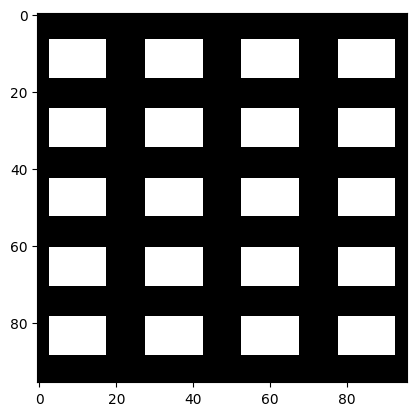

In [8]:
# the model
key_1, subkey_1 = jax.random.split(key)
key_2, subkey_2 = jax.random.split(key_1)
psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
sensor_module = SensorModule(photon_count=photon_count, 
                             noise_enabled=noise_enabled,
                             sensor_array_enabled=sensor_array_enabled, 
                             gaussian_sigma=gaussian_sigma, 
                             sensor_array_params= sensor_array_params)
reconstruction_module = WienerDeconv(log_K)
model = E2E(psf_module=psf_module, sensor_module=sensor_module, reconstruction_module=reconstruction_module)
plt.imshow(model.sensor_module.create_sensor_array(), cmap='gray')
plt.show()

In [ ]:
e2e_optimizer = E2EOptimizer(
    model=model,
    # lr_psf=lr_psf,
    # lr_K=lr_K,
    lr = lr_normal,
    use_wandb=False, #TODO: CHANGE
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

TypeError: string indices must be integers, not 'tuple'

  0%|          | 0/500 [00:00<?, ?it/s]E0304 16:45:05.499438 2186182 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


step 0/500  loss=0.075041  K=0.367512


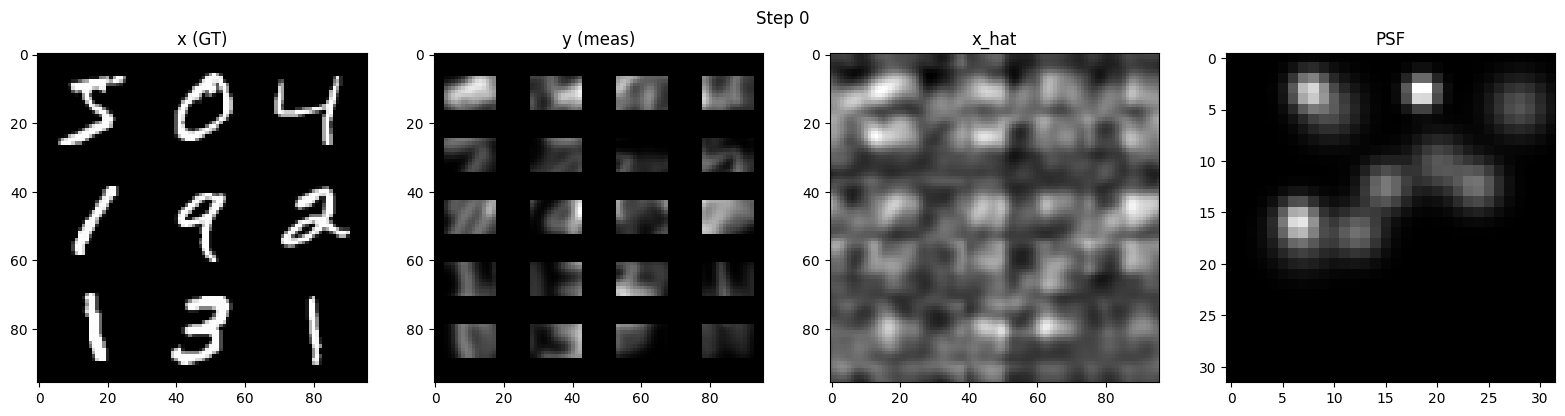

  2%|▏         | 12/500 [00:14<02:57,  2.75it/s] 

step 10/500  loss=0.072424  K=0.363858


  4%|▍         | 22/500 [00:15<01:05,  7.27it/s]

step 20/500  loss=0.080253  K=0.360245


  6%|▋         | 32/500 [00:16<00:45, 10.27it/s]

...

step 80/500  loss=0.078181  K=0.338858


 18%|█▊        | 92/500 [00:22<00:38, 10.66it/s]

step 90/500  loss=0.069679  K=0.335428


 20%|██        | 100/500 [00:22<00:38, 10.36it/s]

step 100/500  loss=0.073081  K=0.332115


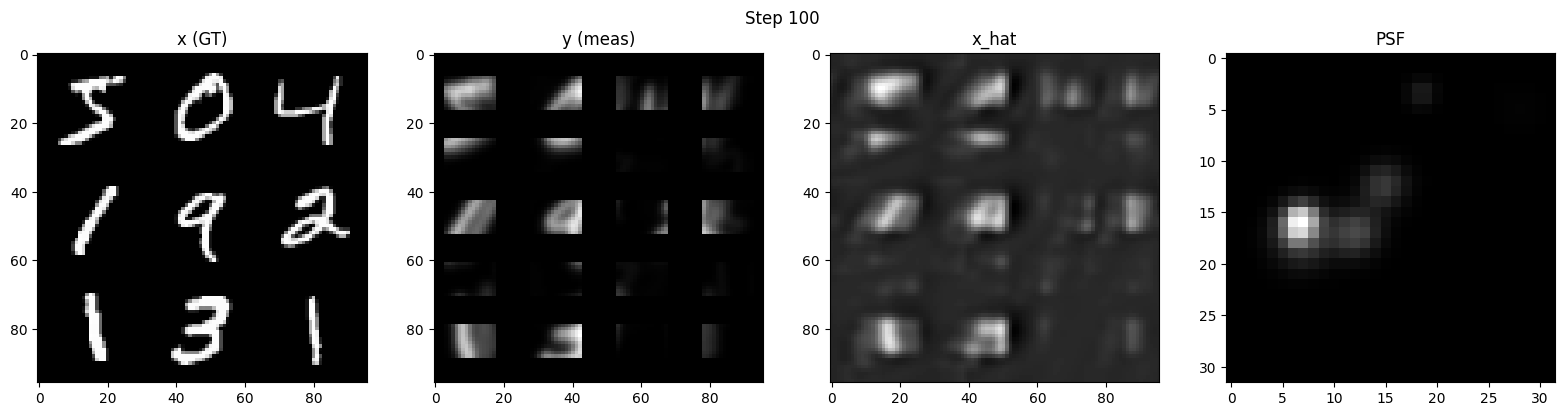

 22%|██▏       | 112/500 [00:24<00:36, 10.62it/s]

step 110/500  loss=0.065049  K=0.328928


 24%|██▍       | 122/500 [00:25<00:35, 10.73it/s]

step 120/500  loss=0.069740  K=0.325785


 26%|██▋       | 132/500 [00:26<00:35, 10.38it/s]

...

step 180/500  loss=0.059072  K=0.306812


 38%|███▊      | 192/500 [00:31<00:27, 11.13it/s]

step 190/500  loss=0.065184  K=0.303806


 40%|████      | 200/500 [00:32<00:30,  9.94it/s]

step 200/500  loss=0.057718  K=0.300899


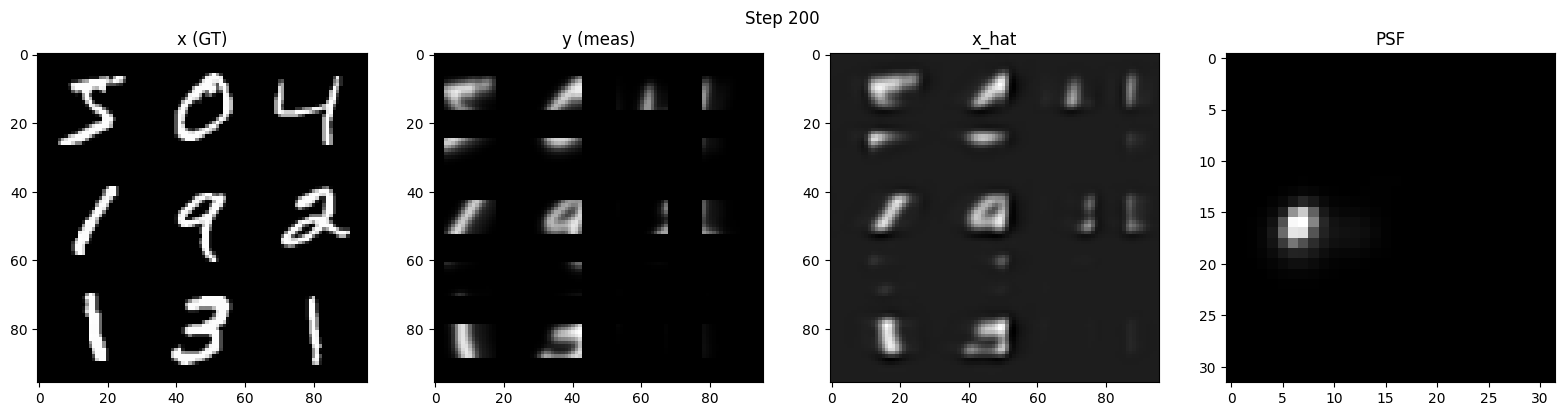

 42%|████▏     | 212/500 [00:36<01:36,  2.99it/s]

step 210/500  loss=0.060085  K=0.298113


 44%|████▍     | 222/500 [00:37<00:33,  8.26it/s]

step 220/500  loss=0.059211  K=0.295386


 46%|████▋     | 232/500 [00:38<00:26, 10.30it/s]

...

step 280/500  loss=0.065262  K=0.280563


 58%|█████▊    | 292/500 [00:44<00:19, 10.59it/s]

step 290/500  loss=0.061218  K=0.278326


 60%|██████    | 300/500 [00:45<00:18, 10.86it/s]

step 300/500  loss=0.057787  K=0.276177


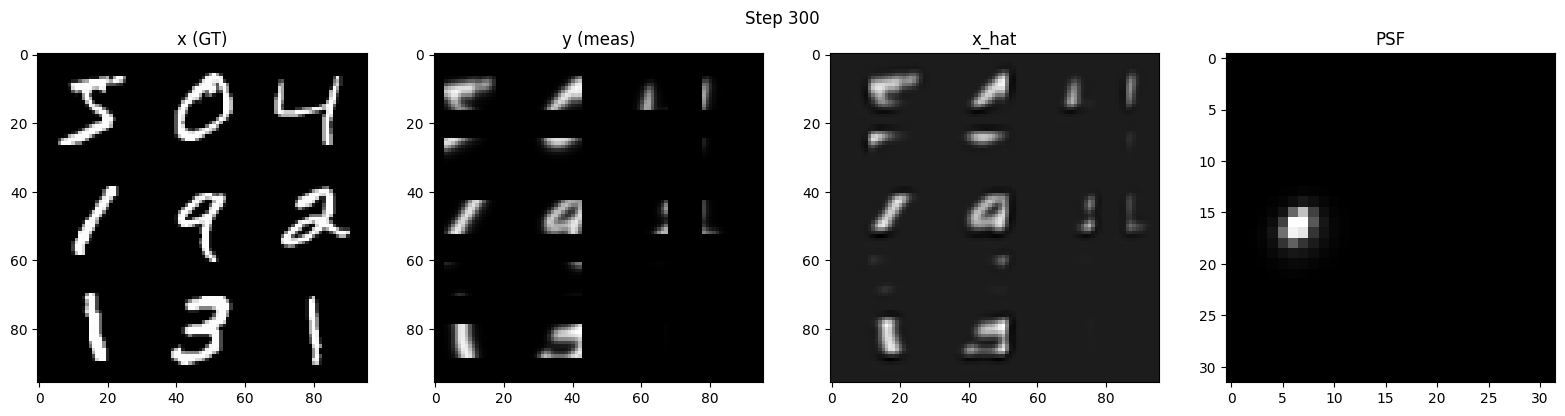

 62%|██████▏   | 312/500 [00:46<00:18,  9.96it/s]

step 310/500  loss=0.063323  K=0.274083


 64%|██████▍   | 322/500 [00:47<00:17,  9.93it/s]

step 320/500  loss=0.062760  K=0.272038


 66%|██████▋   | 332/500 [00:48<00:14, 11.54it/s]

...

step 380/500  loss=0.061239  K=0.260387


 78%|███████▊  | 392/500 [00:53<00:09, 11.23it/s]

step 390/500  loss=0.054777  K=0.258584


 80%|████████  | 400/500 [00:54<00:08, 11.24it/s]

step 400/500  loss=0.062453  K=0.256803


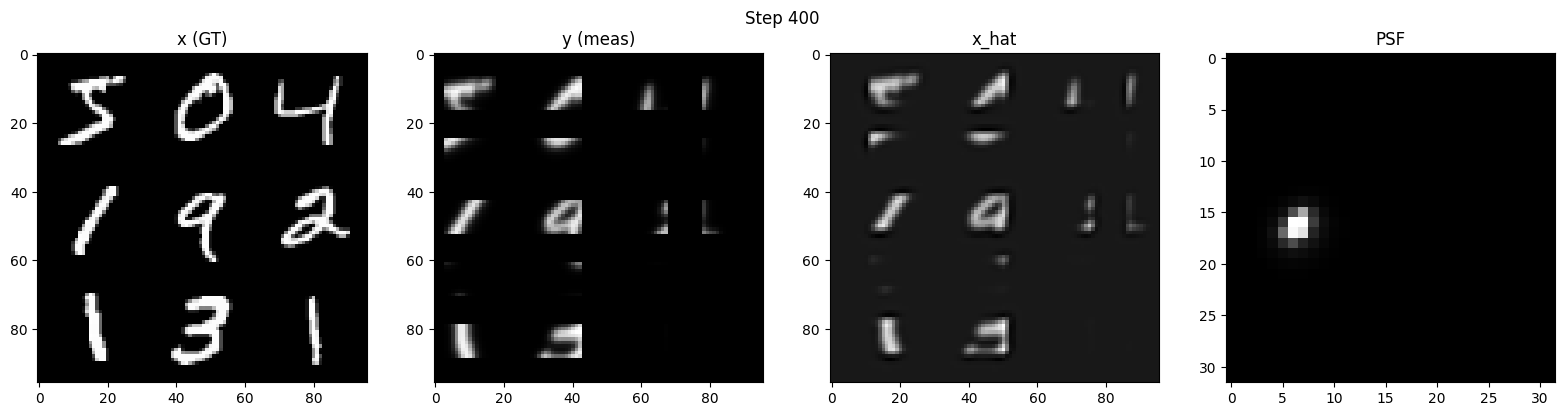

 83%|████████▎ | 413/500 [00:56<00:09,  9.48it/s]

step 410/500  loss=0.055500  K=0.255081


 84%|████████▍ | 421/500 [00:56<00:07, 10.95it/s]

step 420/500  loss=0.060740  K=0.253393


 87%|████████▋ | 433/500 [00:58<00:06, 10.87it/s]

...

step 480/500  loss=0.058051  K=0.244124


 98%|█████████▊| 492/500 [01:03<00:00, 10.26it/s]

step 490/500  loss=0.060816  K=0.242675


100%|█████████▉| 498/500 [01:04<00:00, 10.58it/s]

step 499/500  loss=0.059500  K=0.241416


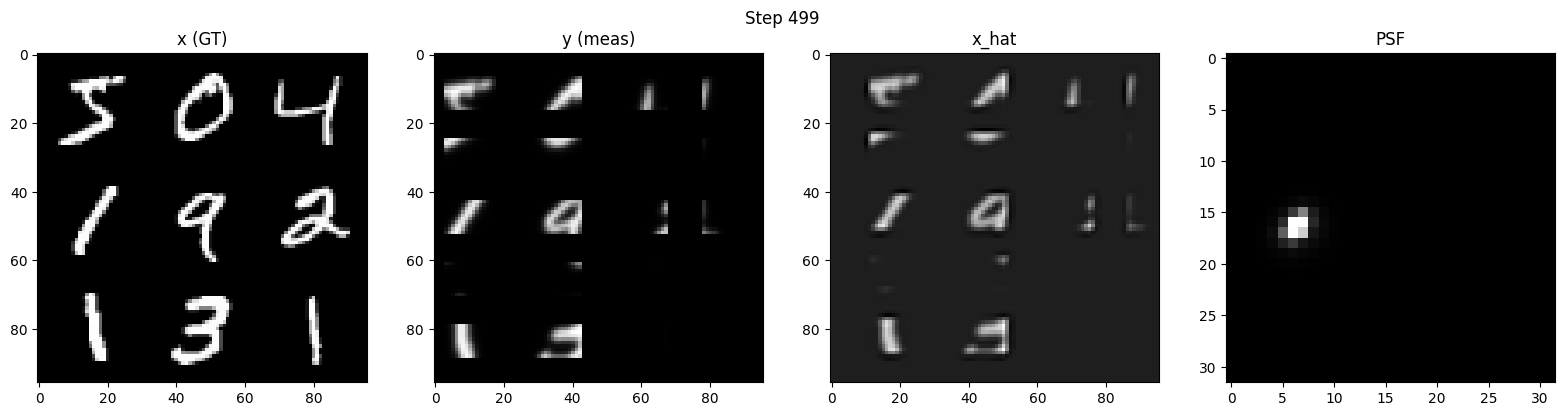

100%|██████████| 500/500 [01:04<00:00,  7.70it/s]


In [ ]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=500,
    log_every=10,
    visualize_every=100,
    key=subkey_2
)

In [ ]:
model.reconstruction_module.log_K

Array(-1., dtype=float32, weak_type=True)